In [110]:
import pandas as pd
import matplotlib.pylab as plt

# Задание 1

In [60]:
df_es = pd.read_csv('Electronic_sales_Sep2023-Sep2024.csv', sep=',')
df_es[['Customer ID', 'Payment Method', 'Total Price', 'Add-on Total']]

,Customer ID,Payment Method,Total Price,Add-on Total
0,1000,Credit Card,5538.33,40.21
1,1000,Paypal,741.09,26.09
2,1002,Credit Card,1855.84,0.00
3,1002,Cash,3164.76,60.16
4,1003,Cash,41.50,35.56
...,...,...,...,...
19995,19996,Bank Transfer,6838.08,0.00
19996,19996,Credit Card,2697.28,0.00
19997,19996,Bank Transfer,1805.90,198.98
19998,19997,Bank Transfer,2528.26,101.34


In [79]:
df_es.groupby("Customer ID")["Payment Method"].count() == 4

Customer ID
1000     False
1002     False
1003     False
1004     False
1005     False
         ...  
19994    False
19995    False
19996    False
19997    False
19998    False
Name: Payment Method, Length: 12136, dtype: bool

In [87]:
for i in range(0, 10):
    print(df_es.groupby("Customer ID").agg({
        "Customer ID": "count"
    })[df_es.groupby("Customer ID")["Payment Method"].count() == i].count())

Customer ID    0
dtype: int64
Customer ID    6637
dtype: int64
Customer ID    3711
dtype: int64
Customer ID    1320
dtype: int64
Customer ID    378
dtype: int64
Customer ID    74
dtype: int64
Customer ID    14
dtype: int64
Customer ID    1
dtype: int64
Customer ID    1
dtype: int64
Customer ID    0
dtype: int64


### Это задание можно понять по разному. Основная интерпретация слов "•	предпочитаемый метод оплаты; " -- это более популярный метод оплаты на основе количества потраченных денег. То есть можно использовать groupby по Customer ID и через agg вывести max по столбцу Total price. Но есть нюанс в виде ID у которых несколько оплат одного типа, а значит их нужно складывать и после этого выводить самый популярный метод оплаты. К сожалению, На решение с данным условием мне не хватает знаний, поэтому будет представлено решение ПО МОЕМУ МНЕНИЮ неверное  

Решение:

In [88]:
df_es.groupby("Customer ID").agg({
    'Payment Method': lambda x: x.mode().iloc[0],
    'Total Price': 'sum',
    'Add-on Total': 'sum'
})

,Payment Method,Total Price,Add-on Total
Customer ID,,,
1000,Credit Card,6279.42,66.30
1002,Cash,5020.60,60.16
1003,Cash,41.50,35.56
1004,Credit Card,83.00,65.78
1005,Debit Card,11779.11,75.33
...,...,...,...
19994,Bank Transfer,5504.87,93.17
19995,Credit Card,5394.56,0.00
19996,Bank Transfer,27296.78,432.12


# Задание 2

In [89]:
df_es

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,NaN,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,NaN,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34


In [13]:
df_es['Shipping Type'].unique()

array(['Standard', 'Overnight', 'Express', 'Same Day', 'Expedited'],
      dtype=object)

In [109]:
zad_1 = {}
for i in df_es['Shipping Type'].unique():
    var = df_es[['Shipping Type', "Total Price"]][df_es['Shipping Type'] == i]
    print(f'{i}, {round(var["Total Price"].sum(), 2)}')
    zad_1.update({i: round(var["Total Price"].sum(), 2)})

Standard, 21343073.55
Overnight, 8704828.17
Express, 8685215.62
Same Day, 12432024.82
Expedited, 12437526.21


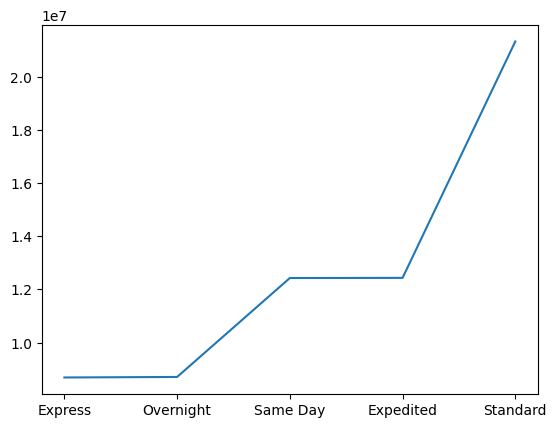

In [123]:
zad1_sort = sorted(zad_1.items(), key=lambda item: item[1])
x,y=zip(*zad1_sort)
plt.plot(x, y)
plt.show()

In [112]:
zad_2 = {}
for i in df_es['Product Type'].unique():
    var = df_es[['Product Type', "Total Price"]][df_es['Product Type'] == i]
    print(f'{i}, {round(var["Total Price"].sum(), 2)}')
    zad_2.update({i: round(var["Total Price"].sum(), 2)})

Smartphone, 21516754.69
Tablet, 11712000.41
Laptop, 12296239.97
Smartwatch, 14036273.06
Headphones, 4041400.24


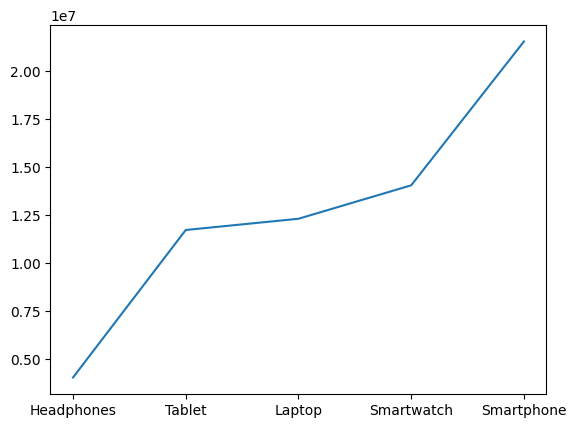

In [124]:
zad2_sort = sorted(zad_2.items(), key=lambda item: item[1])
x,y=zip(*zad2_sort)
plt.plot(x, y)
plt.show()

In [101]:
df_es['Purchase Date'] = pd.to_datetime(df_es['Purchase Date'])

In [103]:
df_es['Month'] = df_es['Purchase Date'].dt.to_period('M')

In [129]:
zad_3 = {}
for i in df_es['Month'].unique():
    var = df_es[['Month', "Add-on Total"]][df_es['Month'] == i]
    print(f'{i}, {round(var["Add-on Total"].sum(), 2)}')
    zad_3.update({str(i): round(var["Add-on Total"].sum(), 2)})

2024-03, 124954.26
2024-04, 123973.59
2023-10, 37837.12
2024-08, 135133.14
2024-05, 132018.51
2024-01, 136195.16
2024-06, 126689.59
2023-11, 34888.81
2023-09, 8012.62
2024-07, 132017.2
2024-09, 99518.89
2023-12, 33509.15
2024-02, 120148.92


In [130]:
zad_3

{'2024-03': 124954.26,
 '2024-04': 123973.59,
 '2023-10': 37837.12,
 '2024-08': 135133.14,
 '2024-05': 132018.51,
 '2024-01': 136195.16,
 '2024-06': 126689.59,
 '2023-11': 34888.81,
 '2023-09': 8012.62,
 '2024-07': 132017.2,
 '2024-09': 99518.89,
 '2023-12': 33509.15,
 '2024-02': 120148.92}

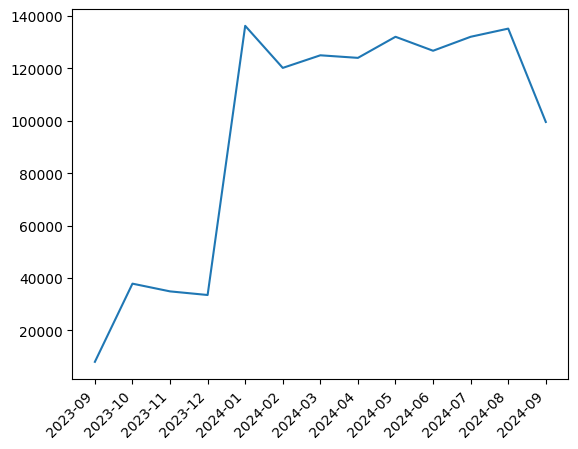

In [139]:
zad3_sort = sorted(zad_3.items(), key=lambda item: item[0])
x,y=zip(*zad3_sort)
plt.plot(x, y)
plt.xticks(rotation=45, ha="right")
plt.show()

In [107]:
df_es['Quarter'] = df_es['Purchase Date'].dt.to_period('Q')

In [137]:
zad_4 = {}
for i in df_es['Quarter'].unique():
    var = df_es[['Quarter', "Add-on Total"]][df_es['Quarter'] == i]
    print(f'{i}, {round(var["Add-on Total"].sum(), 2)}')
    zad_4.update({str(i): round(var["Add-on Total"].sum(), 2)})


2024Q1, 381298.34
2024Q2, 382681.69
2023Q4, 106235.08
2024Q3, 366669.23
2023Q3, 8012.62


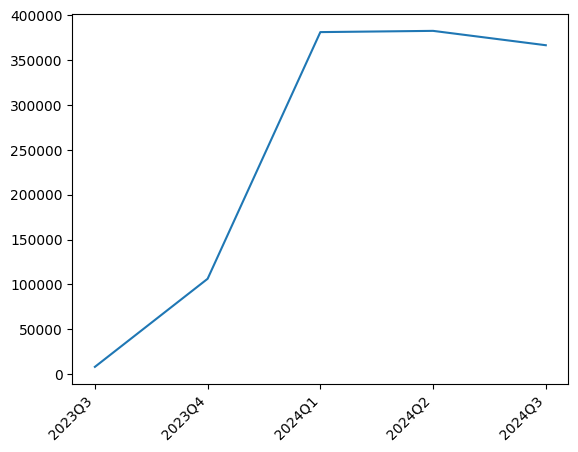

In [140]:
zad4_sort = sorted(zad_4.items(), key=lambda item: item[0])
x,y=zip(*zad4_sort)
plt.plot(x, y)
plt.xticks(rotation=45, ha="right")
plt.show()